In [ ]:
# Titanic Dataset Analysis
### Objective
Analyze the Titanic dataset to understand survival patterns based on gender, passenger class, and age groups using Python, Pandas, Matplotlib, and Seaborn.

In [ ]:
## Step 1: Import Required Libraries and Load Dataset

In this step, we import the necessary Python libraries and load the Titanic dataset into a Pandas DataFrame.

In [2]:
import os
print(os.path.exists("train.csv"))

True


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv")

In [ ]:
## Step 2: Preview Dataset

Display the first five rows of the dataset to understand its structure and available features.

In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
## Step 3: Dataset Information

Check the dataset structure, data types, and identify missing values.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
## Step 4: Missing Value Analysis

Identify columns that contain missing values.

In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
## Step 5: Data Cleaning

Handle missing values in the Age column by replacing them with the mean age of passengers.

In [12]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [13]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
## Step 6: Survival Rate by Gender

Analyze whether gender affected survival chances during the Titanic disaster.

In [14]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [ ]:
### Insight

- Female survival rate: 74.2%
- Male survival rate: 18.9%

**Observation:** Female passengers had a significantly higher survival rate than male passengers.

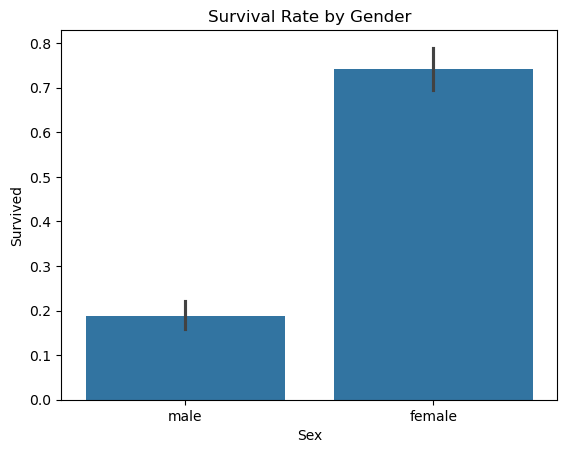

In [15]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title("Survival Rate by Gender")
plt.show()

In [ ]:
## Step 7: Survival Rate by Passenger Class

Analyze whether passenger class influenced survival chances.

In [16]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

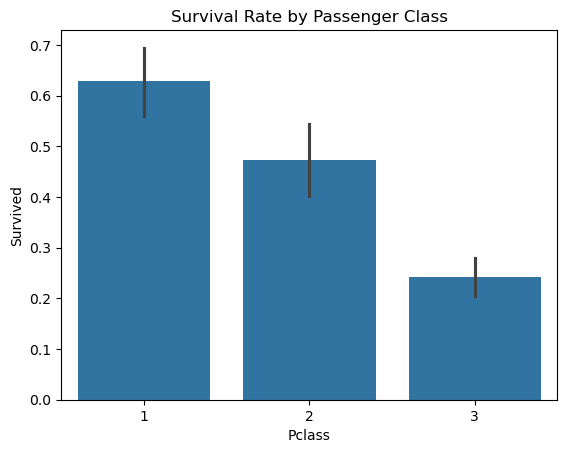

In [17]:
sns.barplot(x='Pclass', y='Survived', data=df)

plt.title("Survival Rate by Passenger Class")

plt.show()

In [ ]:
### Insight

| Passenger Class | Survival Rate |
|----------------|--------------|
| First Class | 62.96% |
| Second Class | 47.28% |
| Third Class | 24.24% |

**Observation:** First-class passengers had the highest survival rate, while third-class passengers had the lowest survival rate.

In [ ]:
## Step 8: Passenger Age Distribution

Visualize the distribution of passenger ages using a histogram.

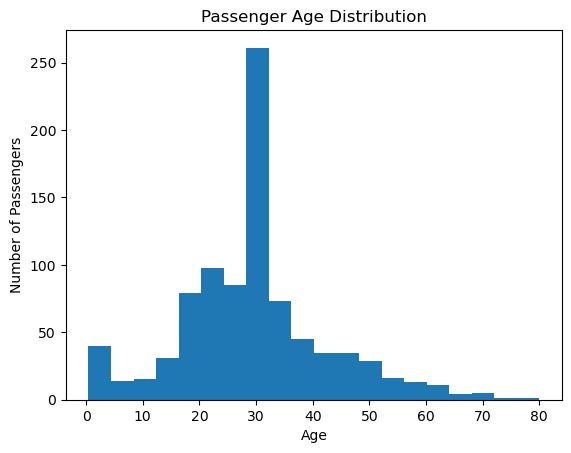

In [18]:
plt.hist(df['Age'], bins=20)

plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

In [ ]:
### Insight

Most passengers were between 20 and 40 years old. The age distribution shows that young adults formed the largest group of passengers aboard the Titanic.

In [ ]:
## Step 9: Survival Rate by Age Group

Passengers are categorized into age groups to analyze how age influenced survival chances.

In [19]:
bins = [0,12,19,35,60,100]

labels = ['Child','Teen','Young Adult','Adult','Senior']

df['AgeGroup'] = pd.cut(df['Age'],
                        bins=bins,
                        labels=labels)

In [20]:
df.groupby('AgeGroup')['Survived'].mean()

C:\Users\aksha\AppData\Local\Temp\ipykernel_2196\2140893742.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['Survived'].mean()


AgeGroup
Child          0.579710
Teen           0.410526
Young Adult    0.352941
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64

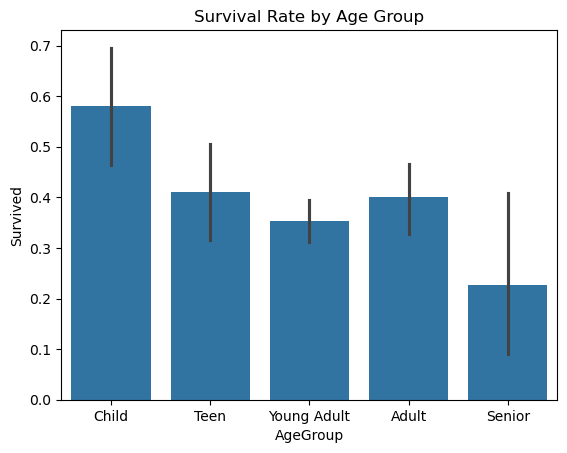

In [21]:
sns.barplot(x='AgeGroup',
            y='Survived',
            data=df)

plt.title("Survival Rate by Age Group")
plt.show()

In [ ]:
### Insight

| Age Group | Survival Rate |
|-----------|--------------|
| Child | 57.97% |
| Teen | 41.05% |
| Young Adult | 35.29% |
| Adult | 40.00% |
| Senior | 22.73% |

**Observation:** Children had the highest survival rate, while senior passengers had the lowest survival rate.

In [ ]:
# Conclusion

### Key Findings

1. Female passengers had a significantly higher survival rate than male passengers.
2. Passenger class strongly affected survival chances.
3. First-class passengers had the highest survival rate.
4. Most passengers were between 20 and 40 years old.
5. Children had better survival chances than older passengers.
6. Senior passengers had the lowest survival rate.

### Outcome

The analysis shows that gender, passenger class, and age all played important roles in determining survival during the Titanic disaster.